<h1 style="font.size:4rem;color:green;">Housing Prices Dataset</h1>

# Load dataset

In [3]:
import pandas as pd

In [4]:
House_price= pd.read_csv("Housing.csv")

## About the dataset

In [5]:
#view the first five row of the dataset
print(House_price.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [6]:
# determine the size of the data i.e the number of rows and column
print(House_price.shape)

(545, 13)


In [7]:
# Show information about the data set
House_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# Data Cleaning

In [8]:
# Number of missing data in the Hosing price dataset
House_price.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

No missing data

In [9]:
# Number of identical rows in the dataset
# Count how many rows are exact duplicates
duplicate_count = House_price.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Total duplicate rows found: 0


In [10]:
# To see the actual rows that are duplicated:
duplicate_rows = House_price[House_price.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [price, area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea, furnishingstatus]
Index: []


# Data Visualization

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis

## Using histograms to show frequency and spread on price distribution 

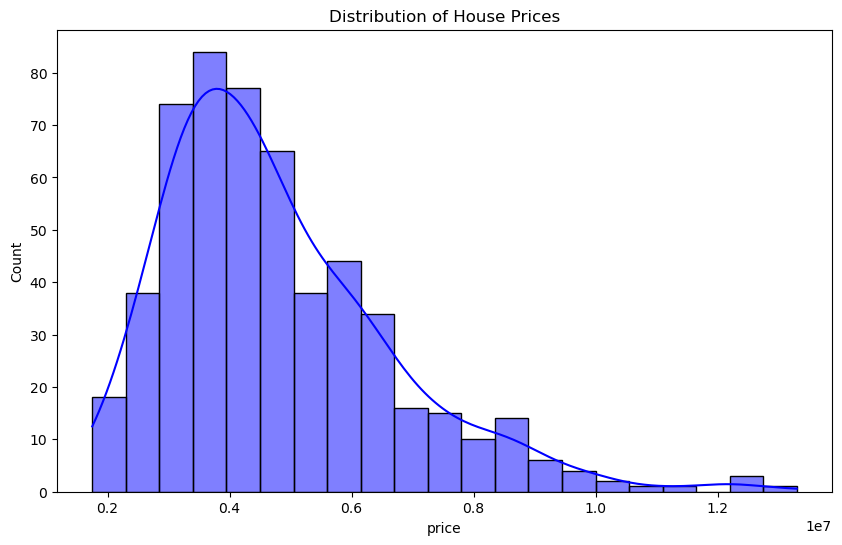

In [12]:
# plot the price distribution
plt.figure(figsize=(10, 6))
sns.histplot(House_price['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.show()

Figure 1 :Distribution of House Prices

In [13]:
skew_value = House_price['price'].skew()
print(f"The skewness of Price is: {skew_value:.2f}")

The skewness of Price is: 1.21


the price is Highly Skewed.

# Bivariate Analysis

Understand the relationship or association between two variables.

## Correlation measures 

first find the Correlation to determine the strength and direction of the relationship (range: -1 to +1)

In [14]:
# Create a copy of original data
House_corr_data = House_price.copy()

In [15]:
# List of Yes/No columns to convert
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

In [16]:
# Convert them to 1 and 0 
for col in binary_cols:
    House_corr_data[col] = House_corr_data[col].map({'yes': 1, 'no': 0})

In [17]:
# For 'furnishingstatus', since it has 3 option, let's use a simple numeric map for now:
# 2: Furnished, 1: Semi-furnished, 0: Unfurnished
furnish_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
House_corr_data['furnishingstatus'] = House_corr_data['furnishingstatus'].map(furnish_map)

Heatmap plot 

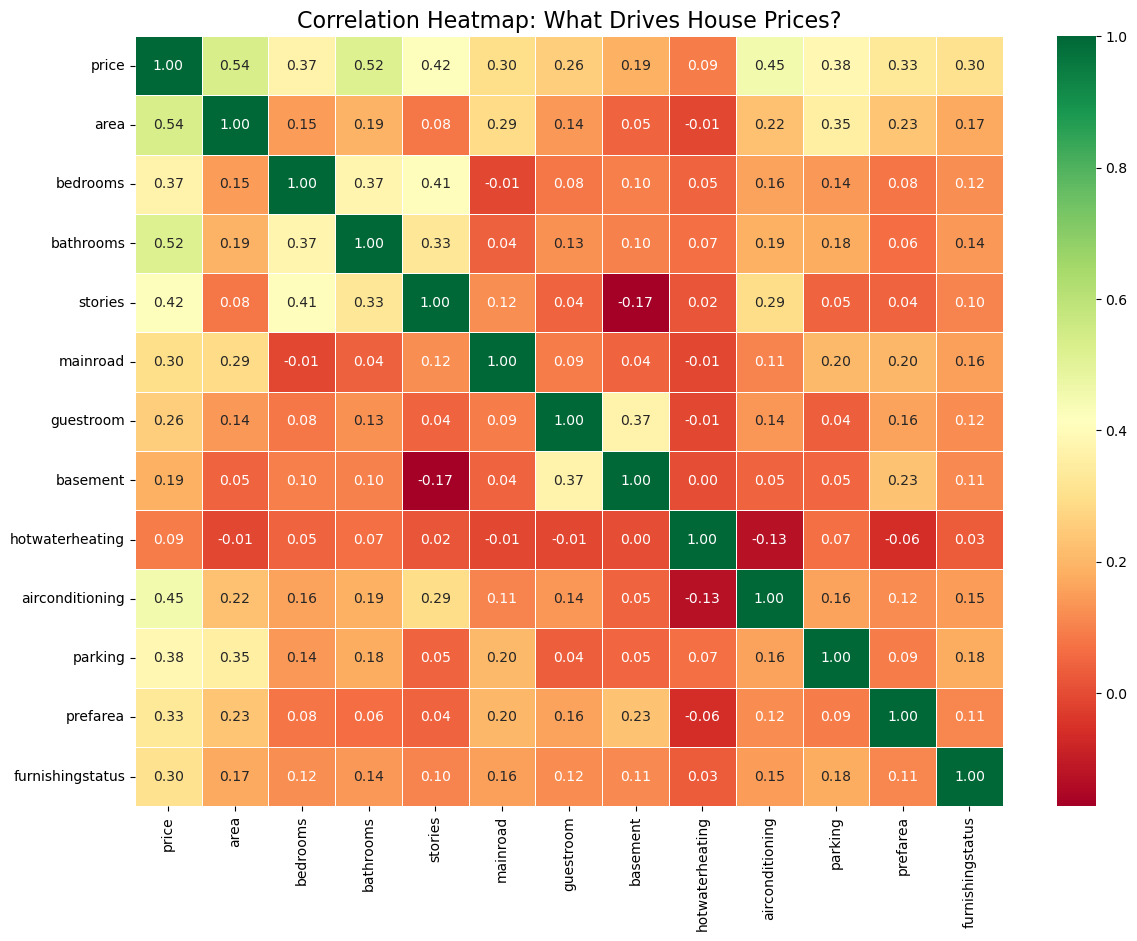

In [18]:
plt.figure(figsize=(14, 10))

# Calculate the correlation matrix
corr_matrix = House_corr_data.corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: What Drives House Prices?', fontsize=16)
plt.show()

Figure 2: Correlation Heatmap: What Drives House Prices?

The analysis reveals that Area, Bathrooms and AC are the primary drivers of house prices. Interestingly, the correlation for Bathrooms (0.52) significantly outperforms the correlation for Bedrooms, suggesting that 'functional luxury' is prioritized over 'room count' in this market.

## Scatter Plot: Area vs. Price

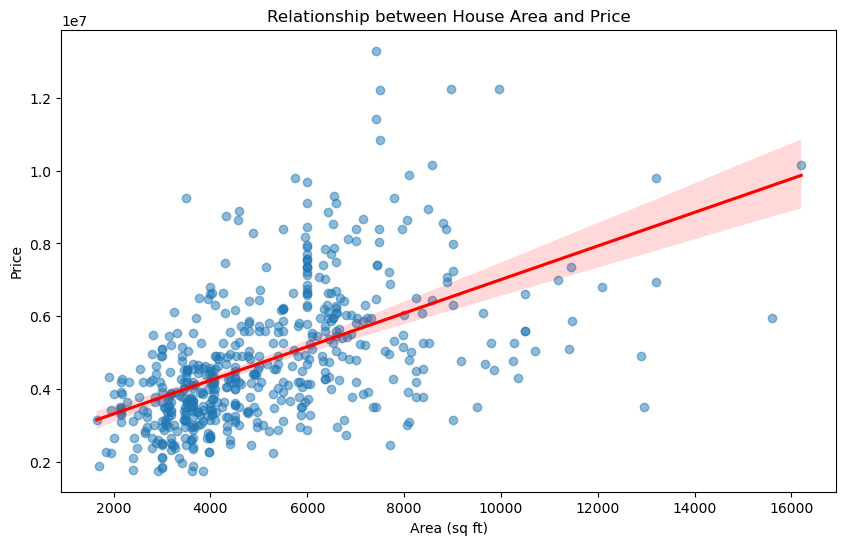

In [19]:
plt.figure(figsize=(10, 6))
sns.regplot(x='area', y='price', data=House_price, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship between House Area and Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.show()

Figure 3: Relationship between House Area and Price

the scatter plot shows that the core market for this dataset consists of houses between 2,000 and 6,500 square feet.Any house larger than 6,500 sq ft is rare in this market. The steady upward slant of that cluster proves that as the housing area move from 2,000 to 6,500 sq ft, so does the price predictable increases.

## Box Plot: Bathrooms vs. Price

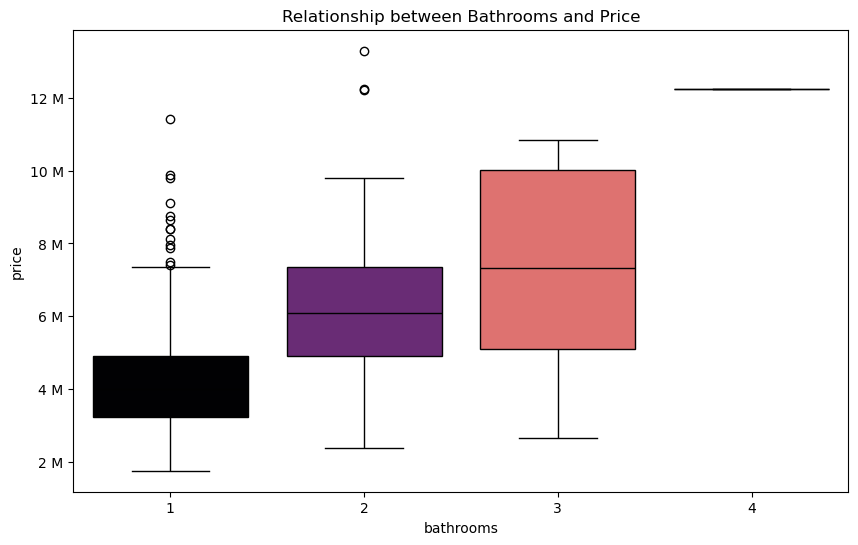

In [20]:
plt.figure(figsize=(10, 6))

# Assigning x to hue and setting legend=False removes the warning
sns.boxplot(x='bathrooms', y='price', data=House_price, hue='bathrooms', palette='magma', legend=False)

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Relationship between Bathrooms and Price')
plt.show()

Figure 4 : Relationship between Bathrooms and Price

the box plot displayed the following:

1 Bathroom (12 Outliers): This means 1-bathroom houses are usually cheap, but there are 12 specific houses with only 1 bathroom that sold for an unusually high price. This suggests those houses might have a massive area or are in a premium location, making them expensive despite having only one bathroom.
2 bathroom (2 outlier): just like the 1 bathroom, it is cheap but only two specfic house with 2 bathroom that sells at an high price.

3 Bathrooms (No Outliers):  3-bedroom houses are very consistent and predictable.

4 Bathrooms (No Box): *"No Box" for 4 bathrooms means you have very few 4-bathroom houses in your dataset. Properties with 4 bathrooms are extremely rare in this dataset, representing a highly exclusive segment.

## Box Plot: Airconditioning vs. Price

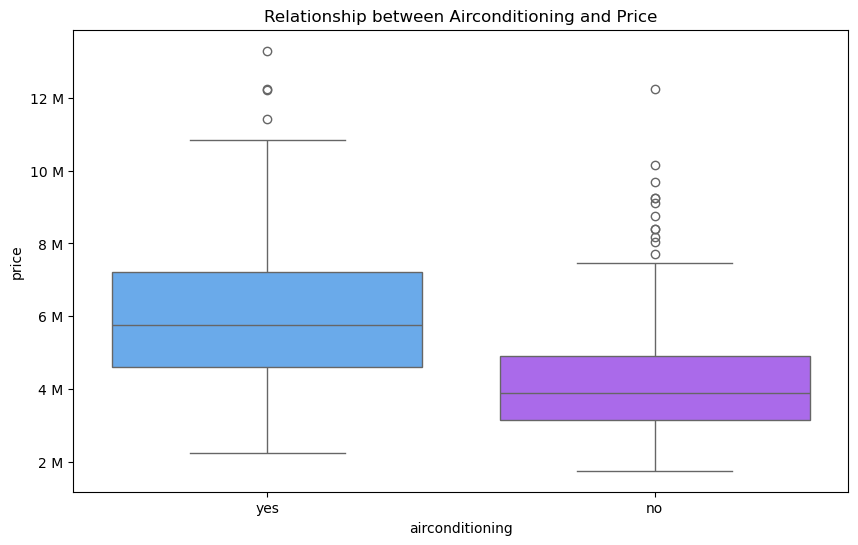

In [21]:
plt.figure(figsize=(10, 6))

# Assigning x to hue and setting legend=False removes the warning
sns.boxplot(x='airconditioning', y='price', data=House_price, hue='airconditioning', palette='cool', legend=False)

import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())

plt.title('Relationship between Airconditioning and Price')
plt.show()

Figure 5: Relationship between Airconditioning and Price

"No" (10 Outliers) vs. "Yes" (3 Outliers): Houses without AC are generally budget standard houses but 10 of them managed to sell for high prices anyway.
Houses with AC have a much higher overall price axis. The fact that it only has 3 outliers means that having AC almost guarantees a high price, so a high price is "normal" for an AC house not an exception.

# Average Price per Square Foot: Standard vs. Prime Locations

In [22]:
# Calculate the Price per Square Foot for every house
House_price['price_per_sqft'] = House_price['price'] / House_price['area']

# Find the average for preferred vs non-preferred areas
location_comparison = House_price.groupby('prefarea')['price_per_sqft'].mean().reset_index()
print(location_comparison)

  prefarea  price_per_sqft
0       no      972.579876
1      yes     1060.917148


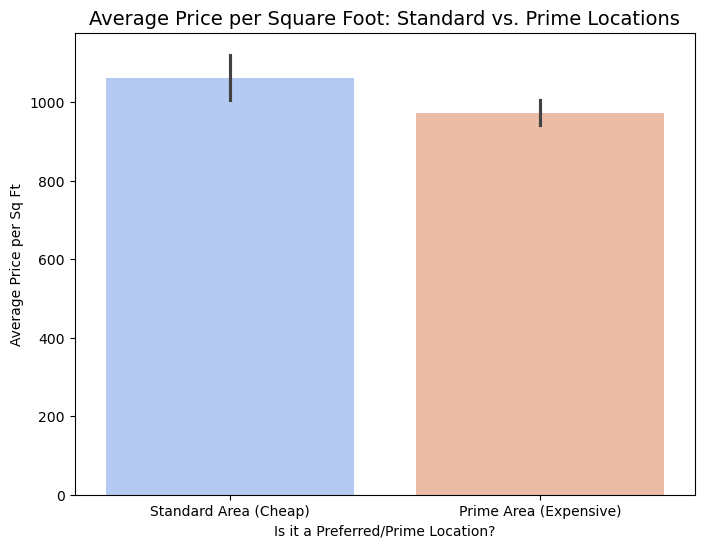

In [23]:
plt.figure(figsize=(8, 6))

# Create the bar plot
sns.barplot(x='prefarea', y='price_per_sqft', data=House_price, hue='prefarea', palette='coolwarm', legend=False)

plt.title('Average Price per Square Foot: Standard vs. Prime Locations', fontsize=14)
plt.xlabel('Is it a Preferred/Prime Location?')
plt.ylabel('Average Price per Sq Ft')
plt.xticks([0, 1], ['Standard Area (Cheap)', 'Prime Area (Expensive)'])

plt.show()

maximum value peaks are observed within Standard Areas reaching up to 1060 per sq ft while the prime is 972per sq ft . This indicates that premium can be override, allowing high-tier houses in standard areas to prime locations.

# Observation/Findings

Based on the analysis, the following structural insights were identified within the housing dataset:

1.) The target variable (price) exhibits a strong right-hand skewness of 1.21. This indicates that the vast majority of properties sit within an affordable baseline, while a small, volatile cluster of high-value luxury outliers pulls the statistical mean upward.

2.) The Bivariate correlation analysis proved that Area (0.54) and Bathrooms (0.52) are the two most powerful linear predictors of property value. Interestingly, bathrooms heavily outperforms bedroom count, signaling that functional utility is prioritized by buyers over sheer room count.

3.) Air conditioning acts as a critical asset threshold. Properties with AC maintain a significantly higher minimum price floor. While non-AC properties dominate the baseline market, they feature severe upward anomalies (outliers), indicating that substantial upgrades are required to make a non-AC home competitive with luxury baselines.

4.) Geographic mapping confirms that Preferred Areas (yes) yield a higher baseline average price per square foot (1,060.92) compared to Standard Areas (972.58). However, the maximum value peaks observed within Standard Areas prove that premium internal asset features such as  air conditioning, structural density and parking can completely override a geographic location penalty, allowing high-tier houses in standard areas to outperform baseline properties in prime locations.

# Conculsion

The Exploratory Data Analysis (EDA) and Data Cleaning phase successfully validated the data integrity of the 13 core features, confirming 0% missing values and 0% exact row duplicates.

From a real estate valuation standpoint, we can conclude that house prices are not driven by a single dominant factor, but rather a strategic combination of scale (Area) and functional luxury (bathrooms). While location (prefarea) establishes the pricing baseline, asset configuration dictates the ultimate value ceiling.